In [1]:
%load_ext autoreload
%autoreload 2

## INTRO & SETTINGS

The goal of this tutorial is to show how to construct confidence sets via **quantile regression**,
using the likelihood-based test statistics `ACORE` and `BFF`, on the "on-off" Poisson counting
experiment described in https://arxiv.org/abs/2107.03920 (Section 5.1 of the EJS paper).

A Poisson counting experiment where particle collision events are counted in the presence of both
an uncertain background process and a (new) signal process:

$$N_b \sim \text{Pois}(\nu \tau b), \qquad N_s \sim \text{Pois}(\nu b + \mu s)$$

The observable data $X = (N_s, N_b)$ contains two measurements. The parameter of interest is the
signal strength $\mu$, whereas the background scaling factor $\nu$ is a nuisance parameter. The
hyperparameters $s$, $b$, $\tau$ (expected signal count, expected background count, and the relative
measurement time between the two regions) are treated as known.

Both `ACORE` and `BFF` estimate an odds function (likelihood up to a normalizing constant) via a
probabilistic classifier, then invert a quantile-regression-based critical value to construct
confidence sets — this is the "quantile regression construction" this notebook is named for.

In [2]:
# SETTINGS

POI_DIM = 1
NUISANCE_DIM = 1
DATA_DIM = 2
BATCH_SIZE = 1  # assume we get to see only one observed sample for each "true" parameter

POI_SPACE_BOUNDS = {'low': 0, 'high': 5}       # mu
NUISANCE_SPACE_BOUNDS = {'low': 0.6, 'high': 1.4}  # nu
POI_GRID_SIZE = 1_000

CONFIDENCE_LEVEL = 0.90

B = 20_000       # simulations to train the test statistic (odds/likelihood-ratio estimator)
B_PRIME = 20_000  # simulations to train the critical-values (quantile regression) calibration model

## SIMULATE

Let's start from the simulator, which is used internally to generate the data needed to
1. estimate the test statistics;
2. estimate the critical values; and
3. diagnose the constructed confidence regions

In [3]:
import torch

from lf2i.simulator.hep import OnOff

onoff = OnOff(
    poi_grid_size=POI_GRID_SIZE,
    batch_size=BATCH_SIZE,
    poi_space_bounds=POI_SPACE_BOUNDS,
    nuisance_space_bounds=NUISANCE_SPACE_BOUNDS,
)

#### Observations

In [4]:
# a signal-like observation (mu away from 0) and a background-only-like observation (mu equal to 0)
x_obs_signal = onoff(param=torch.tensor([[3.0, 1.0]]), batch_size=1).reshape(1, DATA_DIM)
x_obs_null = onoff(param=torch.tensor([[0.0, 1.0]]), batch_size=1).reshape(1, DATA_DIM)

x_obs_signal, x_obs_null

(tensor([[119.,  68.]]), tensor([[72., 68.]]))

## CONFIDENCE SET via ACORE

`ACORE` estimates the full odds function over $(\mu, \nu)$ jointly, then profiles out the nuisance
$\nu$ by numerical optimization at evaluation time (`param_space_bounds` tells it the box over which
to profile). This is the "textbook" nuisance-parameter treatment: nothing about $\nu$ is special-cased
here, it's simply part of the odds function's input.

In [5]:
from lf2i.inference import LF2I
from lf2i.test_statistics import ACORE

acore = ACORE(
    estimator='gb_c',
    poi_dim=POI_DIM,
    nuisance_dim=NUISANCE_DIM,
    batch_size=BATCH_SIZE,
    data_dim=DATA_DIM,
    param_space_bounds=[
        (POI_SPACE_BOUNDS['low'], POI_SPACE_BOUNDS['high']),
        (NUISANCE_SPACE_BOUNDS['low'], NUISANCE_SPACE_BOUNDS['high']),
    ],
    n_jobs=8,
)
lf2i_acore = LF2I(test_statistic=acore)

In [6]:
acore_region_signal = lf2i_acore.inference(
    x=x_obs_signal,
    evaluation_grid=onoff.poi_grid.reshape(-1, 1),
    confidence_level=CONFIDENCE_LEVEL,
    calibration_method='critical-values',
    calibration_model='cat-gb',
    simulator=onoff,
    b=B,
    b_prime=B_PRIME,
)
acore_region_null = lf2i_acore.inference(
    x=x_obs_null,
    evaluation_grid=onoff.poi_grid.reshape(-1, 1),
    confidence_level=CONFIDENCE_LEVEL,
    calibration_method='critical-values',
    calibration_model='cat-gb',
    simulator=onoff,
    b=B,
    b_prime=B_PRIME,
)

Estimating test statistic ...

Calibration ...


Evaluating ACORE for 20000 points...: 100%|██████████| 20000/20000 [01:48<00:00, 184.61it/s]



Retraining calibration...
Fitting 5 folds for each of 25 candidates, totalling 125 fits


/ocean/projects/mth260009p/jcarzon/conda/envs/tsi/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Constructing confidence sets ...


Computing ACORE for 1x500 points...: 100%|██████████| 1/1 [00:04<00:00,  4.33s/it]


Creating set 0...
Estimating test statistic ...



Calibration already complete

Constructing confidence sets ...


Computing ACORE for 1x500 points...: 100%|██████████| 1/1 [00:03<00:00,  3.88s/it]


Creating set 0...


## CONFIDENCE SET via BFF (implicit nuisance marginalization)

`BFF`'s nuisance-marginalization path (numerically integrating the odds function over $\nu$ via
`scipy.integrate.nquad`) turns out to be unimplemented in the current `lf2i` codebase. Rather than
implementing that numerical-integration machinery here, we take the approach of having `BFF`
**implicitly marginalize** over $\nu$: we simulate full $(\mu, \nu)$ pairs from `OnOff` (so $X$ still
reflects the true $\nu$ variability across the training/calibration sets), but only expose $\mu$ to
`BFF`'s odds estimator — i.e. `BFF` is configured with `nuisance_dim=0` and never sees $\nu$ as an
input feature. Since $\nu$ varies across the training distribution but is not conditioned on, the
classifier learns the $\mu$-marginal-over-$\nu$ likelihood ratio automatically, rather than through
explicit integration.

This means we bypass `LF2I.inference`'s `simulator=`/`b=`/`b_prime=` convenience (which would forward
*all* parameter columns unfiltered) and instead build the training (`T`) and calibration (`T_prime`)
sets manually, dropping the $\nu$ column before handing them to `BFF`.

In [7]:
from lf2i.test_statistics import BFF


def simulate_mu_only(size):
    mu = onoff.poi_prior.sample(sample_shape=(size,)).reshape(-1, 1)
    nu = onoff.nuisance_prior.sample(sample_shape=(size,)).reshape(-1, 1)
    samples = onoff(param=torch.hstack((mu, nu)), batch_size=BATCH_SIZE)  # (size, batch_size, data_dim)
    return mu, samples  # nu discarded -> implicit marginalization


T = simulate_mu_only(B)
T_prime = simulate_mu_only(B_PRIME)

bff = BFF(
    estimator='gb_c',
    poi_dim=POI_DIM,
    nuisance_dim=0,
    batch_size=BATCH_SIZE,
    data_dim=DATA_DIM,
    n_jobs=8,
)
lf2i_bff = LF2I(test_statistic=bff)

In [8]:
bff_region_signal = lf2i_bff.inference(
    x=x_obs_signal,
    evaluation_grid=onoff.poi_grid.reshape(-1, 1),
    confidence_level=CONFIDENCE_LEVEL,
    calibration_method='critical-values',
    calibration_model='cat-gb',
    T=T,
    T_prime=T_prime,
)
bff_region_null = lf2i_bff.inference(
    x=x_obs_null,
    evaluation_grid=onoff.poi_grid.reshape(-1, 1),
    confidence_level=CONFIDENCE_LEVEL,
    calibration_method='critical-values',
    calibration_model='cat-gb',
    T=T,
    T_prime=T_prime,
)

Estimating test statistic ...

Calibration ...

Retraining calibration...
Fitting 5 folds for each of 25 candidates, totalling 125 fits

Constructing confidence sets ...

Creating set 0...

Calibration already complete

Constructing confidence sets ...

Creating set 0...


## COMPARISON

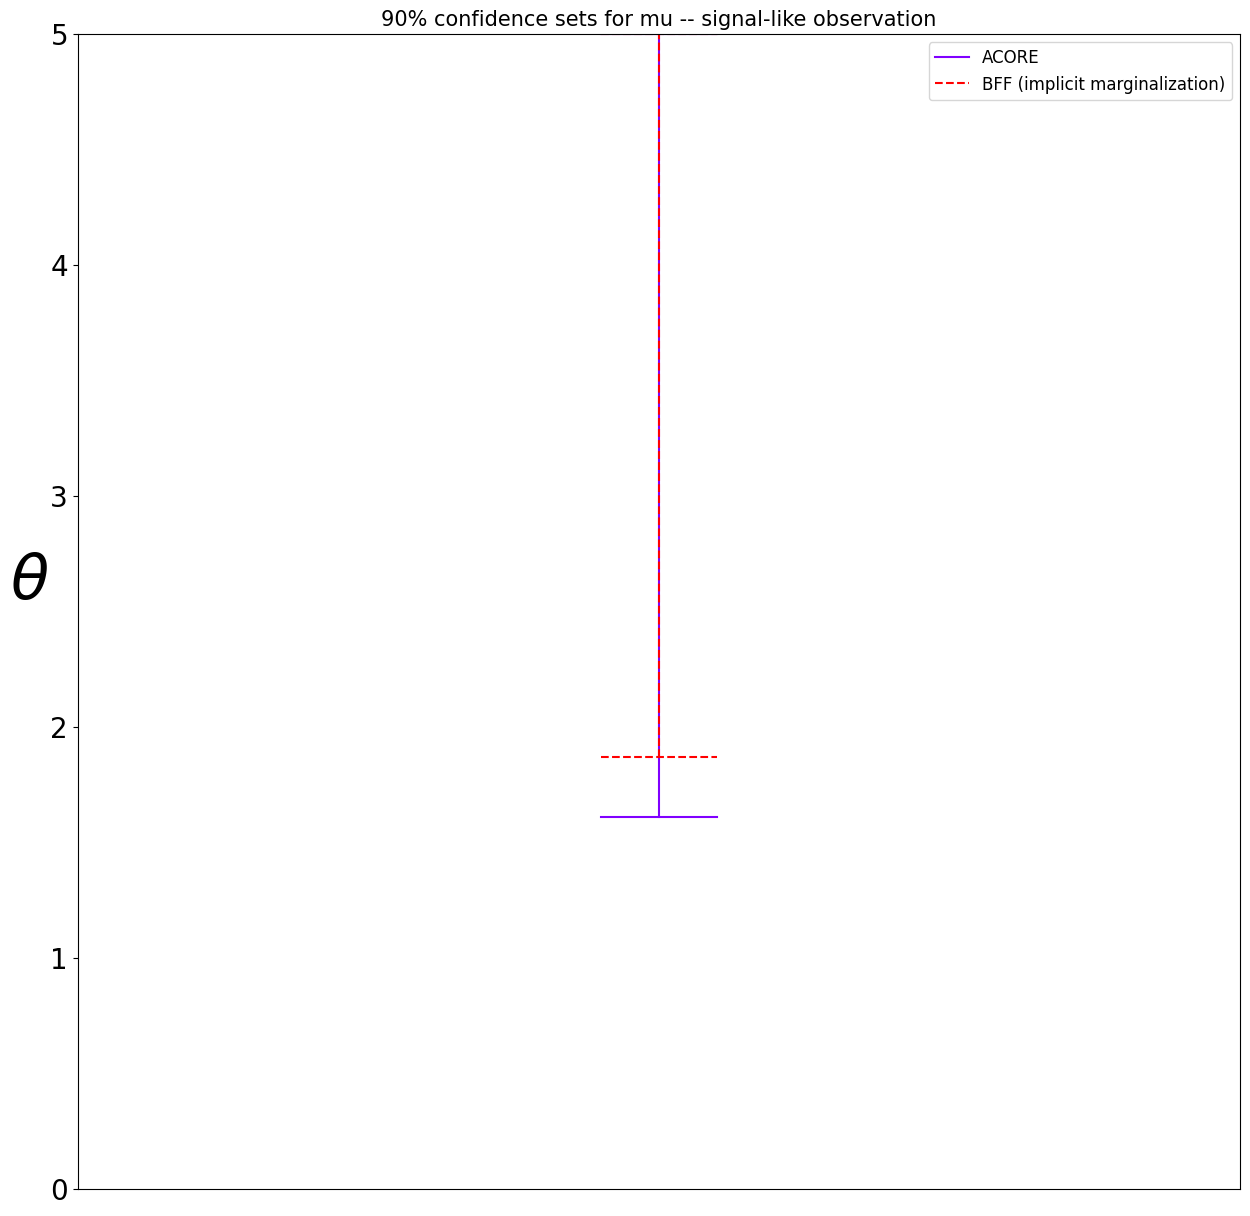

In [9]:
from lf2i.plot.parameter_regions import plot_parameter_regions

plot_parameter_regions(
    acore_region_signal[0], bff_region_signal[0],
    param_dim=POI_DIM,
    parameter_space_bounds=POI_SPACE_BOUNDS,
    region_names=['ACORE', 'BFF (implicit marginalization)'],
    title=f'{int(CONFIDENCE_LEVEL*100)}% confidence sets for mu -- signal-like observation',
)

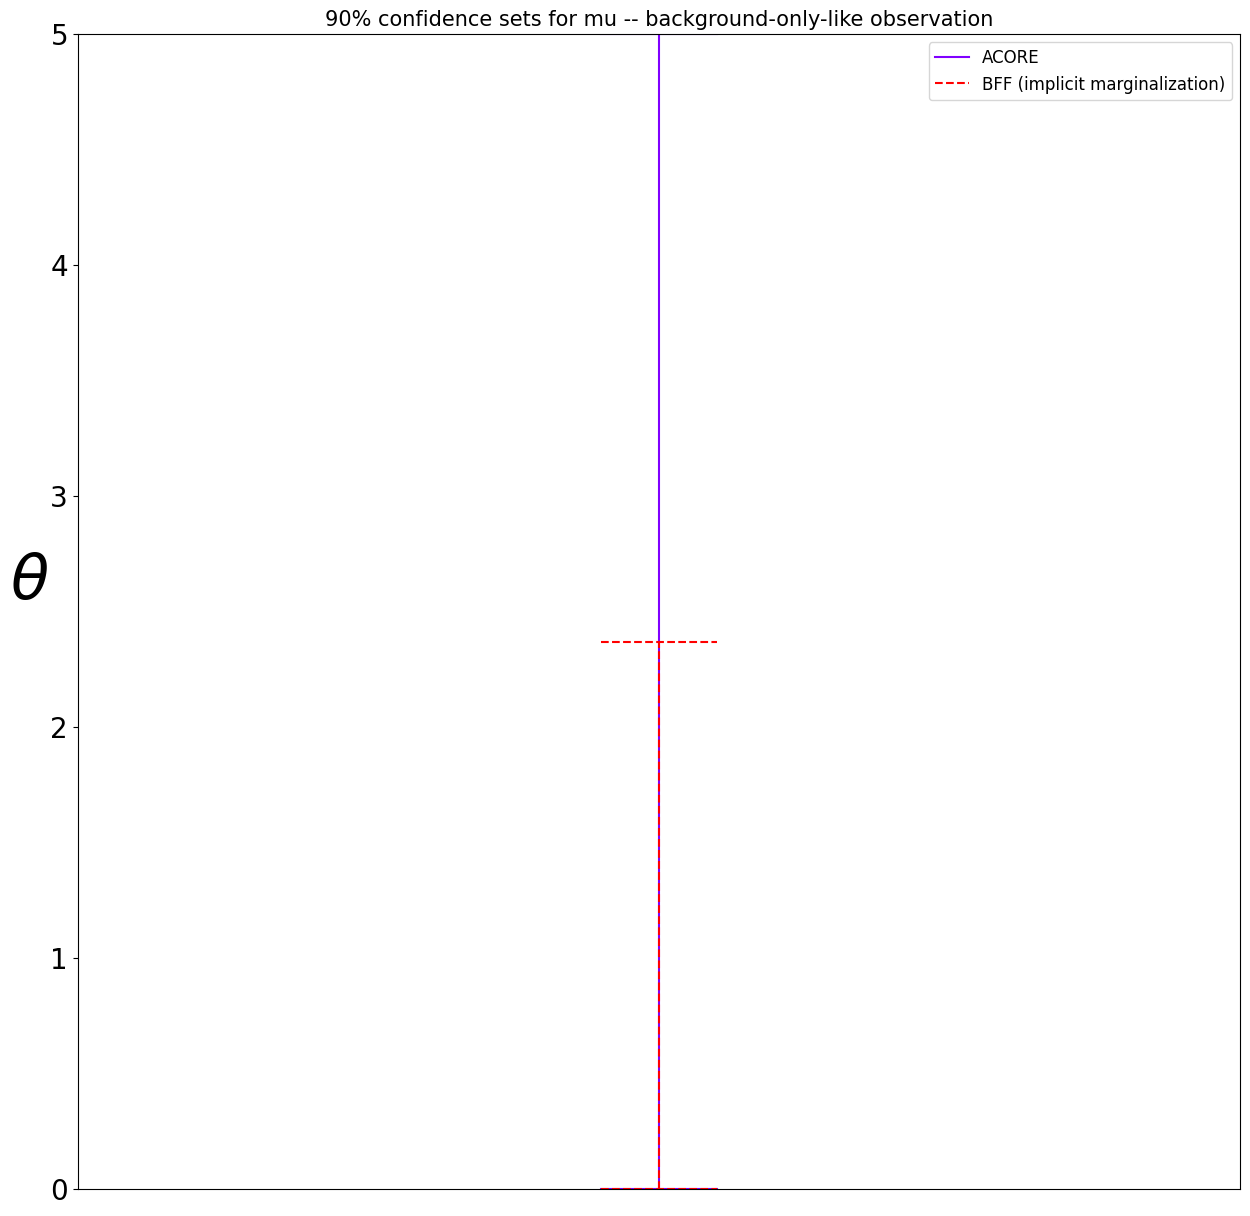

In [10]:
plot_parameter_regions(
    acore_region_null[0], bff_region_null[0],
    param_dim=POI_DIM,
    parameter_space_bounds=POI_SPACE_BOUNDS,
    region_names=['ACORE', 'BFF (implicit marginalization)'],
    title=f'{int(CONFIDENCE_LEVEL*100)}% confidence sets for mu -- background-only-like observation',
)

## EXACT COVERAGE

Since `OnOff` is cheap to simulate, we can check exact (Monte Carlo) coverage of both confidence-set
constructions across the `mu` grid. For `ACORE`, the evaluation grid must include the nuisance
dimension too (`evaluation_grid` needs `param_dim` columns) — we fix `nu` at its nominal value, 1.0,
for this diagnostic slice. For `BFF`, only `mu` is needed, since the nuisance dimension was never part
of its parameter space.

In [11]:
nu_fixed = torch.ones(onoff.poi_grid[::10].shape[0], 1)
acore_coverage_grid = torch.hstack((onoff.poi_grid[::10].reshape(-1, 1), nu_fixed))

acore_grid_out, acore_coverage = lf2i_acore.coverage(
    region_type='lf2i',
    confidence_level=CONFIDENCE_LEVEL,
    calibration_method='critical-values',
    simulator=onoff,
    evaluation_grid=acore_coverage_grid,
    monte_carlo_size=1_000,
    exact=True,
)

Evaluating ACORE for 100000 points...: 100%|██████████| 100000/100000 [07:41<00:00, 216.59it/s]


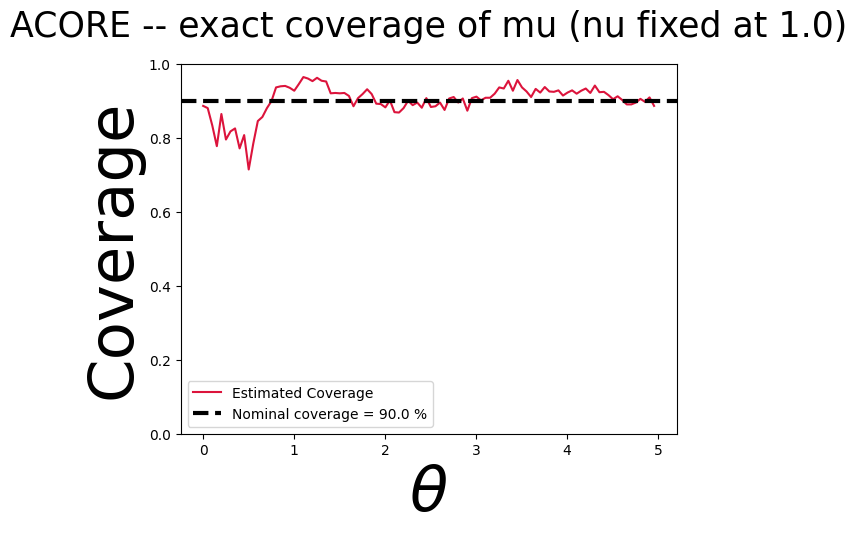

In [12]:
from lf2i.plot.coverage_diagnostics import coverage_probability_plot

coverage_probability_plot(
    parameters=acore_grid_out[:, 0],
    coverage_probability=acore_coverage,
    confidence_level=CONFIDENCE_LEVEL,
    param_dim=POI_DIM,
    title='ACORE -- exact coverage of mu (nu fixed at 1.0)',
)

### BFF -- exact coverage (nu fixed at 1.0)

`LF2I.coverage(exact=True, ...)` can't be reused as-is for `BFF`: internally it simulates data
*and* evaluates the test statistic/calibration model from the same `evaluation_grid` columns (see
`lf2i.diagnostics.monte_carlo_methods.monte_carlo_coverage`). `OnOff` needs both `mu` and `nu` to
simulate, but `BFF`'s odds estimator and calibration model were only ever trained on `mu` (implicit
marginalization, as above). So we write a small helper that decouples the two: the full `(mu, nu)`
grid drives simulation, while only the `mu` column is handed to `BFF.evaluate` and to the
calibration model -- mirroring `simulate_mu_only` from the `BFF` section above, but for coverage
instead of training/calibration.

In [13]:
import numpy as np

from lf2i.utils.miscellanea import to_np_if_torch, to_torch_if_np
from lf2i.utils.calibration_diagnostics_inputs import preprocess_predict_quantile_regression
from lf2i.diagnostics.coverage_probability import compute_indicators_lf2i


def bff_exact_coverage(mu_nu_grid, monte_carlo_size=500):
    """Monte Carlo exact coverage of BFF confidence sets over a (mu, nu) grid.

    `OnOff` needs (mu, nu) to simulate, but BFF's odds estimator/calibration model only ever
    see mu -- so simulation and evaluation use different columns of the same repeated grid,
    unlike `LF2I.coverage(exact=True, ...)`.
    """
    n_grid = mu_nu_grid.shape[0]
    sim_params = to_torch_if_np(np.repeat(to_np_if_torch(mu_nu_grid), monte_carlo_size, axis=0))
    samples = onoff(param=sim_params, batch_size=BATCH_SIZE)

    eval_params = to_np_if_torch(sim_params[:, :1])  # mu only
    ts_values = to_np_if_torch(bff.evaluate(parameters=eval_params, samples=samples, mode='diagnostics')).reshape(-1)

    calib_model = lf2i_bff.calibration_model[f'{CONFIDENCE_LEVEL:.2f}']
    critical_values = to_np_if_torch(calib_model.predict(
        preprocess_predict_quantile_regression(eval_params, calib_model, param_dim=1)
    ))

    indicators = compute_indicators_lf2i(
        calibration_method='critical-values',
        test_statistics=ts_values,
        parameters=eval_params,
        critical_values=critical_values,
        p_values=None,
        alpha=None,
        acceptance_region=bff.acceptance_region,
        param_dim=1,
    )
    return indicators.reshape(n_grid, monte_carlo_size).mean(axis=1)

In [14]:
# reuse the same (mu, nu=1.0) slice as the ACORE exact-coverage grid above, for a direct comparison
bff_coverage = bff_exact_coverage(acore_coverage_grid, monte_carlo_size=1_000)

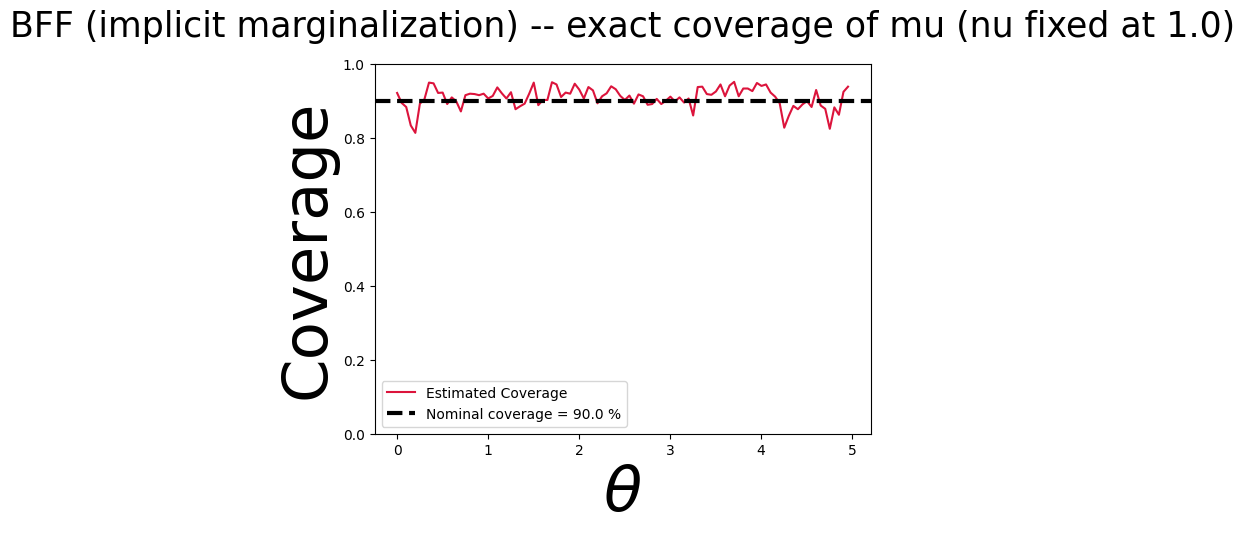

In [15]:
coverage_probability_plot(
    parameters=acore_coverage_grid[:, 0],
    coverage_probability=bff_coverage,
    confidence_level=CONFIDENCE_LEVEL,
    param_dim=POI_DIM,
    title='BFF (implicit marginalization) -- exact coverage of mu (nu fixed at 1.0)',
)

## EXACT COVERAGE OVER (mu, nu)

The slices above fix `nu` at its nominal value 1.0. Since `BFF` marginalizes `nu` out only
*implicitly* (by never conditioning on it, relying on the training distribution to average over
it correctly), it's worth checking coverage on the full `(mu, nu)` plane rather than a single
slice: if `nu` drifts away from where the training prior placed most of its mass, does `BFF`
coverage still hold? `ACORE`, which explicitly profiles `nu`, gives a natural point of comparison
on the same grid.

Note this is `POI_GRID_SIZE // 50 * 20 = 20 * 20 = 400` grid points, each needing its own Monte
Carlo batch.

In [16]:
mu_2d = onoff.poi_grid[::50]  # 20 points
nu_2d = torch.linspace(NUISANCE_SPACE_BOUNDS['low'], NUISANCE_SPACE_BOUNDS['high'], steps=20)
mu_nu_grid_2d = torch.cartesian_prod(mu_2d, nu_2d)  # (400, 2): mu varies slower, nu faster

In [17]:
acore_2d_grid_out, acore_2d_coverage = lf2i_acore.coverage(
    region_type='lf2i',
    confidence_level=CONFIDENCE_LEVEL,
    calibration_method='critical-values',
    simulator=onoff,
    evaluation_grid=mu_nu_grid_2d,
    monte_carlo_size=300,
    exact=True,
)

Evaluating ACORE for 120000 points...: 100%|██████████| 120000/120000 [10:00<00:00, 199.87it/s]


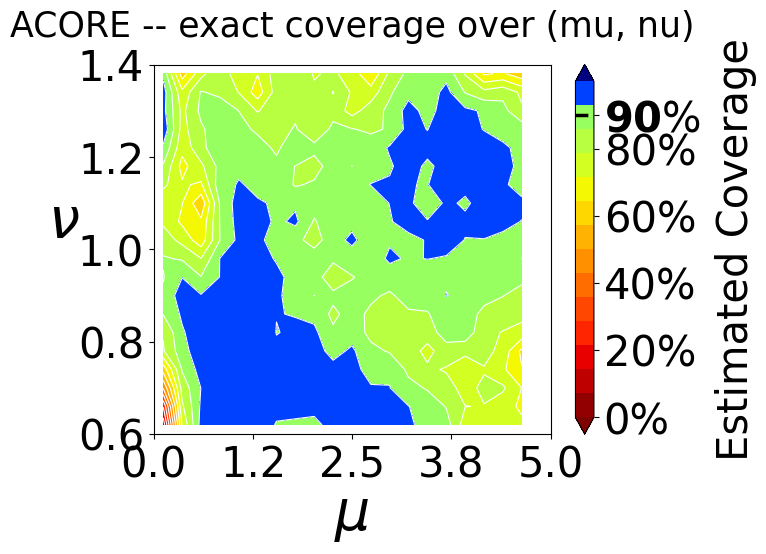

In [29]:
coverage_probability_plot(
    parameters=acore_2d_grid_out,
    coverage_probability=acore_2d_coverage,
    confidence_level=CONFIDENCE_LEVEL,
    param_dim=2,
    params_labels=[r'$\mu$', r'$\nu$'],
    xlims=(POI_SPACE_BOUNDS['low'], POI_SPACE_BOUNDS['high']),
    ylims=(NUISANCE_SPACE_BOUNDS['low'], NUISANCE_SPACE_BOUNDS['high']),
    n_bins=20,
    title='ACORE -- exact coverage over (mu, nu)',
)

In [19]:
bff_2d_coverage = bff_exact_coverage(mu_nu_grid_2d, monte_carlo_size=300)

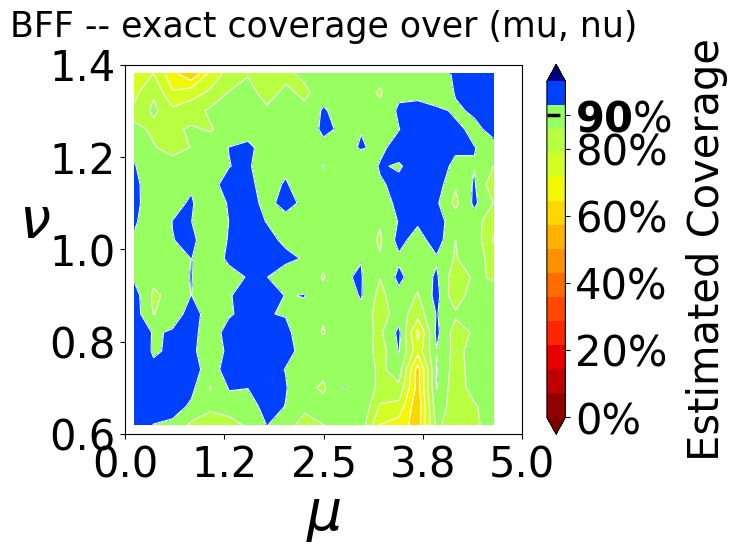

In [30]:
coverage_probability_plot(
    parameters=mu_nu_grid_2d,
    coverage_probability=bff_2d_coverage,
    confidence_level=CONFIDENCE_LEVEL,
    param_dim=2,
    params_labels=[r'$\mu$', r'$\nu$'],
    xlims=(POI_SPACE_BOUNDS['low'], POI_SPACE_BOUNDS['high']),
    ylims=(NUISANCE_SPACE_BOUNDS['low'], NUISANCE_SPACE_BOUNDS['high']),
    n_bins=20,
    title='BFF -- exact coverage over (mu, nu)',
)